# Hybrid CNN + VI — Notebook Minimal (Training-only)

Notebook ini **HANYA berisi cell wajib** untuk training Hybrid CNN + VI dari nol.

**Yang TIDAK ada:**
- Cell ekstrak fitur whole-image (cell 14 lama ~10 menit) — diganti load CSV cache
- Cell SVM experiment (cell 27 ~5 menit) — bisa di-load dari pkl/joblib kalau perlu
- Cell CNN murni (cell 70-78) — tidak diperlukan untuk training hybrid
- Cell patch experiment (cell 56-67) — tidak diperlukan
- Cell EDA, visualisasi panjang, dll

**Output**: `best_hybrid_cnn_{VI}.keras` + `hybrid_results.pkl` di Google Drive.

**Estimasi runtime**: 40-50 menit di Colab T4.

## 1. Setup — Import & Mount Drive

In [1]:
import os, glob, zipfile, warnings, shutil, random, gc, time, pickle
import numpy as np
import pandas as pd
import cv2
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from collections import Counter

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score, recall_score)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.utils import resample
from skimage.feature import graycomatrix, graycoprops

warnings.filterwarnings('ignore')
print('Imports selesai')

Imports selesai


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import glob as _glob

DRIVE_ROOT = '/content/drive/MyDrive'
search_patterns = [
    f'{DRIVE_ROOT}/padi*.zip',
    f'{DRIVE_ROOT}/*/padi*.zip',          # 1 level subfolder
    f'{DRIVE_ROOT}/*/*/padi*.zip',        # 2 level subfolder
]
candidates = []
for pat in search_patterns:
    candidates.extend(_glob.glob(pat))

if candidates:
    ZIP_PATH  = sorted(candidates)[-1]
    DRIVE_DIR = os.path.dirname(ZIP_PATH)
    print(f'Dataset ditemukan : {ZIP_PATH}')
    print(f'DRIVE_DIR         : {DRIVE_DIR}')
else:
    raise FileNotFoundError(
        f'Upload padi*.zip ke Drive (root MyDrive atau subfolder).'
    )

Dataset ditemukan : /content/drive/MyDrive/thesis-shared/padi.v10i.folder.zip
DRIVE_DIR         : /content/drive/MyDrive/thesis-shared


In [4]:
EXTRACT_DIR = '/content/padi_dataset'

if not os.path.isdir(EXTRACT_DIR) or not os.listdir(EXTRACT_DIR):
    os.makedirs(EXTRACT_DIR, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_DIR)
    print(f'Extracted ke {EXTRACT_DIR}')
else:
    print(f'Dataset sudah ada di {EXTRACT_DIR}, skip extract')

DATA_ROOT = EXTRACT_DIR
for sp in ['train', 'valid', 'test']:
    p = os.path.join(DATA_ROOT, sp)
    if not os.path.isdir(p):
        raise RuntimeError(f'Folder {sp} tidak ditemukan di {DATA_ROOT}')
print('Isi DATA_ROOT:', os.listdir(DATA_ROOT))

Extracted ke /content/padi_dataset
Isi DATA_ROOT: ['train', 'valid', 'test', 'README.roboflow.txt', 'README.dataset.txt']


## 2. VI Functions & Konfigurasi

In [5]:
def read_rgb(path):
    bgr = cv2.imread(path, cv2.IMREAD_COLOR)
    if bgr is None:
        return None
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

def green_mask(rgb, threshold=5, min_green=40):
    """Masking piksel vegetasi hijau."""
    R = rgb[:,:,0].astype(np.int32)
    G = rgb[:,:,1].astype(np.int32)
    B = rgb[:,:,2].astype(np.int32)
    return (G > R + threshold) & (G > B + threshold) & (G > min_green)

# ── 7 Indeks Vegetasi ──────────────────────────────────────────────────────────

def compute_VARI(rgb, eps=1e-6):
    """Visible Atmospherically Resistant Index: (G-R)/(G+R-B)"""
    r = rgb.astype(np.float32)
    R, G, B = r[:,:,0], r[:,:,1], r[:,:,2]
    return np.clip((G - R) / (G + R - B + eps), -1.0, 1.0)

def compute_ExG(rgb):
    """Excess Green Index: (2G - R - B) / 255"""
    r = rgb.astype(np.float32)
    R, G, B = r[:,:,0], r[:,:,1], r[:,:,2]
    return (2*G - R - B) / 255.0

def compute_ExGR(rgb):
    """Excess Green minus Excess Red: ExG - 1.4R - G"""
    r = rgb.astype(np.float32) / 255.0
    R, G, B = r[:,:,0], r[:,:,1], r[:,:,2]
    ExG = 2*G - R - B
    ExR = 1.4*R - G
    return ExG - ExR

def compute_GLI(rgb, eps=1e-6):
    """Green Leaf Index: (2G - R - B) / (2G + R + B)"""
    r = rgb.astype(np.float32)
    R, G, B = r[:,:,0], r[:,:,1], r[:,:,2]
    return (2*G - R - B) / (2*G + R + B + eps)

def compute_MGRVI(rgb, eps=1e-6):
    """Modified Green Red Vegetation Index: (G² - R²) / (G² + R²)"""
    r = rgb.astype(np.float32)
    R, G = r[:,:,0], r[:,:,1]
    return (G**2 - R**2) / (G**2 + R**2 + eps)

def compute_RGBVI(rgb, eps=1e-6):
    """RGB Vegetation Index: (G² - B·R) / (G² + B·R)"""
    r = rgb.astype(np.float32)
    R, G, B = r[:,:,0], r[:,:,1], r[:,:,2]
    return (G**2 - B*R) / (G**2 + B*R + eps)

def compute_NGRDI(rgb, eps=1e-6):
    """Normalized Green Red Difference Index: (G - R) / (G + R)"""
    r = rgb.astype(np.float32)
    R, G = r[:,:,0], r[:,:,1]
    return (G - R) / (G + R + eps)

# Registry semua indeks vegetasi
VI_REGISTRY = {
    "VARI":  compute_VARI,
    "ExG":   compute_ExG,
    "ExGR":  compute_ExGR,
    "GLI":   compute_GLI,
    "MGRVI": compute_MGRVI,
    "RGBVI": compute_RGBVI,
    "NGRDI": compute_NGRDI,
}

print(f"Total indeks vegetasi terdaftar: {len(VI_REGISTRY)}")
for name, fn in VI_REGISTRY.items():
    print(f"  - {name:6s}: {fn.__doc__.split(':')[0].strip()}")


Total indeks vegetasi terdaftar: 7
  - VARI  : Visible Atmospherically Resistant Index
  - ExG   : Excess Green Index
  - ExGR  : Excess Green minus Excess Red
  - GLI   : Green Leaf Index
  - MGRVI : Modified Green Red Vegetation Index
  - RGBVI : RGB Vegetation Index
  - NGRDI : Normalized Green Red Difference Index


In [6]:
def compute_glcm_features(gray):
    """Ekstrak 8 fitur GLCM: contrast, correlation, energy, homogeneity (mean+std)."""
    g = gray.astype(np.uint8)
    glcm = graycomatrix(g, distances=[1,3], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                        levels=256, symmetric=True, normed=True)
    feats = {}
    for prop in ['contrast','correlation','energy','homogeneity']:
        vals = graycoprops(glcm, prop).flatten()
        feats[f'glcm_{prop}_mean'] = float(np.mean(vals))
        feats[f'glcm_{prop}_std']  = float(np.std(vals))
    return feats

def extract_vi_stats(vi_1d):
    """10 statistik dari array 1D indeks vegetasi."""
    v = vi_1d.flatten()
    return {
        "mean":      float(np.mean(v)),
        "std":       float(np.std(v)),
        "median":    float(np.median(v)),
        "p10":       float(np.percentile(v, 10)),
        "p25":       float(np.percentile(v, 25)),
        "p75":       float(np.percentile(v, 75)),
        "p90":       float(np.percentile(v, 90)),
        "frac_gt0":  float(np.mean(v > 0)),
        "frac_gt01": float(np.mean(v > 0.1)),
        "iqr":       float(np.percentile(v, 75) - np.percentile(v, 25)),
    }

USE_GREEN_MASK = True
IMAGE_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
STAT_NAMES = list(extract_vi_stats(np.array([0])).keys())
GLCM_NAMES = [f'glcm_{p}_{s}' for p in ['contrast','correlation','energy','homogeneity'] for s in ['mean','std']]

print(f"Fitur statistik VI : {len(STAT_NAMES)} fitur")
print(f"Fitur GLCM         : {len(GLCM_NAMES)} fitur")
print(f"Total per VI       : {len(STAT_NAMES) + len(GLCM_NAMES)} fitur")
print(f"Total semua VI     : {(len(STAT_NAMES) + len(GLCM_NAMES)) * len(VI_REGISTRY)} fitur")


Fitur statistik VI : 10 fitur
Fitur GLCM         : 8 fitur
Total per VI       : 18 fitur
Total semua VI     : 126 fitur


In [7]:
CLASS_ORDER = ['Vegetative', 'Generative', 'Mature']
VI_NAMES    = list(VI_REGISTRY.keys())

# Label encoder bisa langsung fit dari CLASS_ORDER (tidak butuh df_all)
le = LabelEncoder()
le.fit(CLASS_ORDER)

print(f'CLASS_ORDER : {CLASS_ORDER}')
print(f'VI_NAMES    : {VI_NAMES}')
print(f'Encoding    : {dict(zip(CLASS_ORDER, le.transform(CLASS_ORDER)))}')

CLASS_ORDER : ['Vegetative', 'Generative', 'Mature']
VI_NAMES    : ['VARI', 'ExG', 'ExGR', 'GLI', 'MGRVI', 'RGBVI', 'NGRDI']
Encoding    : {'Vegetative': np.int64(2), 'Generative': np.int64(0), 'Mature': np.int64(1)}


## 3. TensorFlow Setup

In [8]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

# Suppress TF warnings (tf.function retracing dll)
tf.get_logger().setLevel('ERROR')

print('TensorFlow:', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print('GPU:', gpus if gpus else 'TIDAK ADA (CPU sangat lambat untuk training!)')

# Config CNN
IMG_SIZE        = 224
BATCH_SIZE      = 16
EPOCHS_HEAD_HY  = 5
EPOCHS_FT_HY    = 10

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 4. Resample Training Set (Balance Class)

Target: Vegetative 300 (under), Generative 245 (keep), Mature 300 (over).

In [9]:
BALANCED_ROOT = '/content/padi_balanced'
TARGET_COUNTS = {'Vegetative': 300, 'Generative': 245, 'Mature': 300}
RNG_SEED      = 42

if os.path.exists(BALANCED_ROOT):
    shutil.rmtree(BALANCED_ROOT)

random.seed(RNG_SEED)
balanced_train = os.path.join(BALANCED_ROOT, 'train')
os.makedirs(balanced_train, exist_ok=True)

for cls in CLASS_ORDER:
    src_dir = os.path.join(DATA_ROOT, 'train', cls)
    dst_dir = os.path.join(balanced_train, cls)
    os.makedirs(dst_dir, exist_ok=True)

    src_files = []
    for ext in IMAGE_EXTS:
        src_files.extend(glob.glob(os.path.join(src_dir, f'*{ext}')))

    target = TARGET_COUNTS[cls]
    n_src  = len(src_files)

    if n_src >= target:
        chosen = random.sample(src_files, target)
        for src in chosen:
            shutil.copy(src, dst_dir)
    else:
        for src in src_files:
            shutil.copy(src, dst_dir)
        n_extra = target - n_src
        for i in range(n_extra):
            src  = random.choice(src_files)
            base = os.path.basename(src)
            stem, ext = os.path.splitext(base)
            dst  = os.path.join(dst_dir, f'{stem}_dup{i+1}{ext}')
            shutil.copy(src, dst)

    final_count = len(os.listdir(dst_dir))
    print(f'  {cls:12s}: src={n_src:>3d} -> balanced={final_count:>3d}')

total = sum(len(os.listdir(os.path.join(balanced_train, c))) for c in CLASS_ORDER)
print(f'\nTotal training images (balanced): {total}')

  Vegetative  : src=306 -> balanced=300
  Generative  : src=138 -> balanced=245
  Mature      : src= 57 -> balanced=300

Total training images (balanced): 845


## 5. Pre-compute VI Features Cache

Hitung sekali 18 fitur (10 stats + 8 GLCM) per gambar per VI, cache di RAM agar training loop tidak perlu recompute.

In [10]:
def extract_vi_features_for_image(image_path, vi_name):
    """Ekstrak 18 fitur: 10 stats VI + 8 GLCM."""
    rgb = read_rgb(image_path)
    if rgb is None:
        return None
    vi_map = VI_REGISTRY[vi_name](rgb)
    stats  = extract_vi_stats(vi_map.flatten())
    gray   = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    glcm   = compute_glcm_features(gray)
    feats  = [stats[s] for s in STAT_NAMES] + [glcm[g] for g in GLCM_NAMES]
    return np.array(feats, dtype=np.float32)

# Kumpulkan path: balanced train + valid + test
all_image_paths = []
for split_root, split_name in [(balanced_train, 'train'),
                                (os.path.join(DATA_ROOT, 'valid'), 'valid'),
                                (os.path.join(DATA_ROOT, 'test'),  'test')]:
    for cls in CLASS_ORDER:
        cls_dir = os.path.join(split_root, cls)
        if not os.path.isdir(cls_dir):
            continue
        for ext in IMAGE_EXTS:
            for p in glob.glob(os.path.join(cls_dir, f'*{ext}')):
                all_image_paths.append((p, cls, split_name))

print(f'Total image paths: {len(all_image_paths)}')
print(f'Precomputing VI features: {len(VI_NAMES)} VI x {len(all_image_paths)} images...')

vi_features_cache = {}
for vi_name in VI_NAMES:
    fail = 0
    for path, _, _ in tqdm(all_image_paths, desc=vi_name, leave=False):
        feats = extract_vi_features_for_image(path, vi_name)
        if feats is None:
            fail += 1
            continue
        vi_features_cache[(path, vi_name)] = feats
    if fail:
        print(f'  {vi_name}: {fail} gagal')

print(f'\nCache siap: {len(vi_features_cache):,} entries')

Total image paths: 916
Precomputing VI features: 7 VI x 916 images...



Cache siap: 6,412 entries


## 6. HybridSequence & Build Hybrid Model

In [11]:
class HybridSequence(tf.keras.utils.Sequence):
    """Generator yang yield ([image_batch, vi_batch], label_batch)."""
    def __init__(self, image_paths, labels, vi_name,
                 batch_size=16, augment=False, shuffle=True):
        self.image_paths = list(image_paths)
        self.labels      = np.array(labels)
        self.vi_name     = vi_name
        self.batch_size  = batch_size
        self.augment     = augment
        self.shuffle     = shuffle
        self.n_classes   = len(CLASS_ORDER)
        self.indices     = np.arange(len(self.image_paths))
        if shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.image_paths) / self.batch_size))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __getitem__(self, idx):
        batch_idx = self.indices[idx*self.batch_size:(idx+1)*self.batch_size]
        imgs, vis, labs = [], [], []

        for i in batch_idx:
            path = self.image_paths[i]
            img  = tf.keras.utils.load_img(path, target_size=(IMG_SIZE, IMG_SIZE))
            arr  = tf.keras.utils.img_to_array(img)

            if self.augment:
                arr = self._apply_augment(arr)

            arr = preprocess_input(arr)
            imgs.append(arr)

            vi_feat = vi_features_cache.get((path, self.vi_name))
            if vi_feat is None:
                vi_feat = np.zeros(18, dtype=np.float32)
            vis.append(vi_feat)

            labs.append(self.labels[i])

        X_img = np.array(imgs, dtype=np.float32)
        X_vi  = np.array(vis,  dtype=np.float32)
        y_oh  = tf.keras.utils.to_categorical(np.array(labs), num_classes=self.n_classes)
        return (X_img, X_vi), y_oh

    def _apply_augment(self, arr):
        if np.random.rand() < 0.5: arr = np.fliplr(arr)
        if np.random.rand() < 0.5: arr = np.flipud(arr)
        k = np.random.randint(0, 4)
        if k: arr = np.rot90(arr, k)
        arr = np.clip(arr * np.random.uniform(0.7, 1.3), 0, 255)
        return arr

print('HybridSequence siap')

HybridSequence siap


In [12]:
def build_hybrid_model(n_vi_features=18, n_classes=3, dropout=0.3):
    """EfficientNetB0(RGB) + VI features -> Classifier head."""
    image_input = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='image_input')
    base_model  = EfficientNetB0(
        weights='imagenet', include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
    )
    base_model.trainable = False
    x_img = base_model(image_input, training=False)
    x_img = layers.GlobalAveragePooling2D()(x_img)

    vi_input = keras.Input(shape=(n_vi_features,), name='vi_input')
    x_vi     = layers.BatchNormalization()(vi_input)

    concat = layers.Concatenate()([x_img, x_vi])
    x      = layers.Dense(128, activation='relu')(concat)
    x      = layers.Dropout(dropout)(x)
    x      = layers.Dense(64,  activation='relu')(x)
    out    = layers.Dense(n_classes, activation='softmax')(x)

    return keras.Model(inputs=[image_input, vi_input], outputs=out), base_model

print('build_hybrid_model siap')

build_hybrid_model siap


## 7. Setup Paths & Class Weights

In [13]:
def collect_paths_labels(root_dir, class_order):
    paths, labels = [], []
    for idx, cls in enumerate(class_order):
        cls_dir = os.path.join(root_dir, cls)
        if not os.path.isdir(cls_dir):
            continue
        for ext in IMAGE_EXTS:
            for p in sorted(glob.glob(os.path.join(cls_dir, f'*{ext}'))):
                paths.append(p)
                labels.append(idx)
    return paths, np.array(labels)

train_paths, train_labels = collect_paths_labels(balanced_train,                       CLASS_ORDER)
valid_paths, valid_labels = collect_paths_labels(os.path.join(DATA_ROOT, 'valid'),     CLASS_ORDER)
test_paths,  test_labels  = collect_paths_labels(os.path.join(DATA_ROOT, 'test'),      CLASS_ORDER)

print(f'Train: {len(train_paths)} | Valid: {len(valid_paths)} | Test: {len(test_paths)}')

hybrid_class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels,
)
hybrid_class_weight_dict = {i: float(w) for i, w in enumerate(hybrid_class_weights_arr)}
print(f'Class weights: {hybrid_class_weight_dict}')

Train: 845 | Valid: 36 | Test: 35
Class weights: {0: 0.9388888888888889, 1: 1.1496598639455782, 2: 0.9388888888888889}


## 8. Training Loop — 7 VI Eksperimen

**Yang paling lama** (~30-50 menit). Pakai anti-idle JS di DevTools sebelum mulai.

Setelah tiap VI selesai → auto-save partial ke pickle (anti hilang).

In [14]:
hybrid_results = []
HYBRID_PKL = f'{DRIVE_DIR}/hybrid_results.pkl'

for vi_idx, vi_name in enumerate(VI_NAMES, start=1):
    print('\n' + '='*60)
    print(f'  [{vi_idx}/{len(VI_NAMES)}] HYBRID CNN + {vi_name}')
    print('='*60)
    t0 = time.time()

    train_seq = HybridSequence(train_paths, train_labels, vi_name,
                                batch_size=BATCH_SIZE, augment=True,  shuffle=True)
    valid_seq = HybridSequence(valid_paths, valid_labels, vi_name,
                                batch_size=BATCH_SIZE, augment=False, shuffle=False)
    test_seq  = HybridSequence(test_paths,  test_labels,  vi_name,
                                batch_size=BATCH_SIZE, augment=False, shuffle=False)

    model, base = build_hybrid_model(n_vi_features=18)
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss='categorical_crossentropy', metrics=['accuracy'])

    # Phase 1: head only
    print(f'  Phase 1: head only ({EPOCHS_HEAD_HY} epochs)')
    cb1 = [keras.callbacks.EarlyStopping(monitor='val_loss', patience=3,
                                          restore_best_weights=True)]
    h1  = model.fit(train_seq, epochs=EPOCHS_HEAD_HY, validation_data=valid_seq,
                    class_weight=hybrid_class_weight_dict, callbacks=cb1, verbose=0)

    # Phase 2: fine-tune top 30 layers
    base.trainable = True
    for layer in base.layers[:-30]:
        layer.trainable = False
    model.compile(optimizer=keras.optimizers.Adam(1e-5),
                  loss='categorical_crossentropy', metrics=['accuracy'])

    print(f'  Phase 2: fine-tune top 30 layers ({EPOCHS_FT_HY} epochs)')
    cb2 = [keras.callbacks.EarlyStopping(monitor='val_loss', patience=4,
                                          restore_best_weights=True),
           keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                              patience=2, min_lr=1e-7)]
    h2  = model.fit(train_seq, epochs=EPOCHS_FT_HY, validation_data=valid_seq,
                    class_weight=hybrid_class_weight_dict, callbacks=cb2, verbose=0)

    # Evaluasi test set
    y_pred_proba = model.predict(test_seq, verbose=0)
    y_pred       = np.argmax(y_pred_proba, axis=1)
    y_true       = test_labels

    test_acc  = accuracy_score(y_true, y_pred)
    test_f1   = f1_score(y_true, y_pred, average='macro')
    recalls   = recall_score(y_true, y_pred, average=None,
                              labels=range(len(CLASS_ORDER)))
    recall_d  = {cls: float(r) for cls, r in zip(CLASS_ORDER, recalls)}

    elapsed = time.time() - t0
    print(f'  Test Acc={test_acc:.4f}  F1={test_f1:.4f}  '
          f'Mature Recall={recall_d["Mature"]:.2f}  ({elapsed:.0f}s)')

    hybrid_results.append({
        'vi':            vi_name,
        'test_acc':      test_acc,
        'test_f1_macro': test_f1,
        'recall_veg':    recall_d['Vegetative'],
        'recall_gen':    recall_d['Generative'],
        'recall_mat':    recall_d['Mature'],
        'elapsed_sec':   elapsed,
        'y_pred':        y_pred.copy(),
    })

    # INCREMENTAL SAVE: save setelah TIAP VI (anti hilang kalau disconnect)
    with open(HYBRID_PKL, 'wb') as f:
        pickle.dump(hybrid_results, f)
    print(f'  [saved {len(hybrid_results)} results to {HYBRID_PKL}]')

    # Cleanup memory
    del model, base, train_seq, valid_seq, test_seq, h1, h2
    keras.backend.clear_session()
    gc.collect()

hybrid_df = pd.DataFrame(hybrid_results).sort_values('test_f1_macro', ascending=False)
print('\n' + '='*60)
print('  RANKING HYBRID CNN + VI')
print('='*60)
print(hybrid_df[['vi','test_acc','test_f1_macro','recall_mat']].to_string(index=False))


  [1/7] HYBRID CNN + VARI
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
  Phase 1: head only (5 epochs)
  Phase 2: fine-tune top 30 layers (10 epochs)
  Test Acc=0.9429  F1=0.8917  Mature Recall=0.80  (225s)
  [saved 1 results to /content/drive/MyDrive/thesis-shared/hybrid_results.pkl]

  [2/7] HYBRID CNN + ExG
  Phase 1: head only (5 epochs)
  Phase 2: fine-tune top 30 layers (10 epochs)
  Test Acc=0.9714  F1=0.9475  Mature Recall=1.00  (172s)
  [saved 2 results to /content/drive/MyDrive/thesis-shared/hybrid_results.pkl]

  [3/7] HYBRID CNN + ExGR
  Phase 1: head only (5 epochs)
  Phase 2: fine-tune top 30 layers (10 epochs)
  Test Acc=0.9714  F1=0.9475  Mature Recall=1.00  (162s)
  [saved 3 results to /content/drive/MyDrive/thesis-shared/hybrid_results.pkl]

  [4/7] HYBRID CNN + GLI
  Phase 1: head only (5 epochs)
  Phase 2: fine-tune top 30 layers (10 epochs)
  Test Acc=0.9429  F1=0.8917  Mature Recall=0.80  (167s)
  [saved 4 results to /content/drive/MyDrive/thesis-shared/hyb

## 9. Visualisasi Hasil

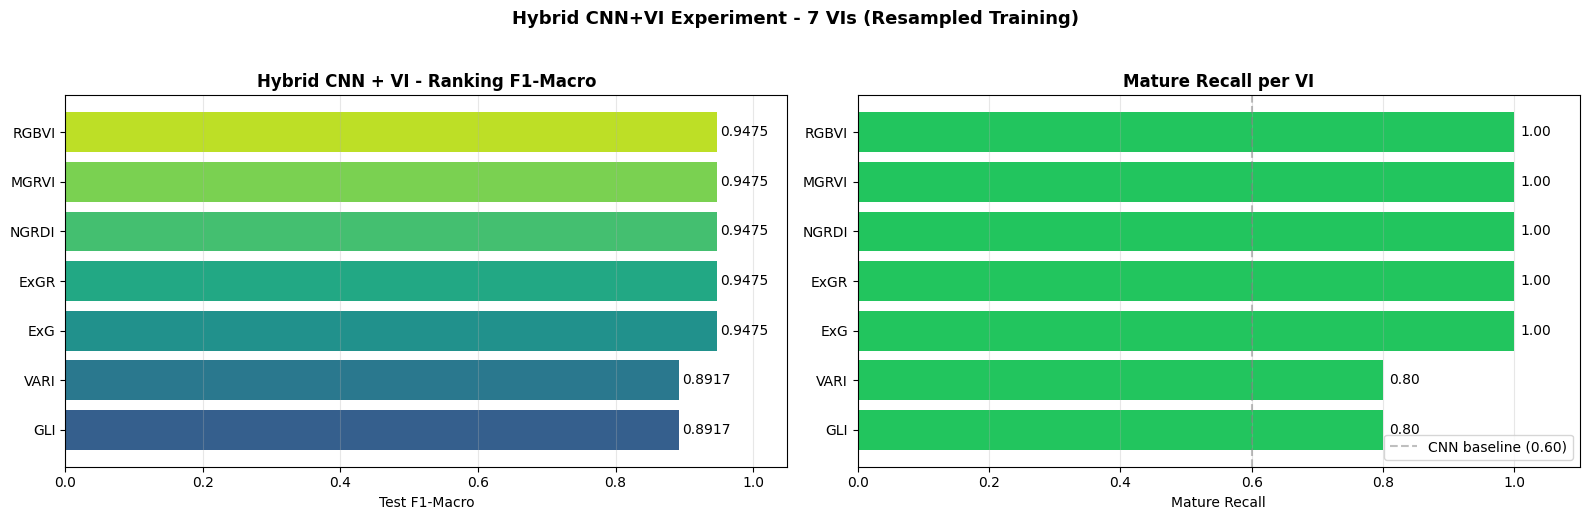


VI terbaik: ExG
  Test F1-Macro : 0.9475
  Mature Recall : 1.0000


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df_sorted = hybrid_df.sort_values('test_f1_macro', ascending=True)
colors1   = plt.cm.viridis(np.linspace(0.3, 0.9, len(df_sorted)))
axes[0].barh(df_sorted['vi'], df_sorted['test_f1_macro'], color=colors1)
for i, (vi, f1) in enumerate(zip(df_sorted['vi'], df_sorted['test_f1_macro'])):
    axes[0].text(f1 + 0.005, i, f'{f1:.4f}', va='center', fontsize=10)
axes[0].set_xlabel('Test F1-Macro')
axes[0].set_title('Hybrid CNN + VI - Ranking F1-Macro', fontweight='bold')
axes[0].set_xlim(0, 1.05)
axes[0].grid(axis='x', alpha=0.3)

df_sorted2 = hybrid_df.sort_values('recall_mat', ascending=True)
colors2    = ['#22c55e' if r >= 0.8 else '#eab308' if r >= 0.6 else '#ef4444'
              for r in df_sorted2['recall_mat']]
axes[1].barh(df_sorted2['vi'], df_sorted2['recall_mat'], color=colors2)
for i, (vi, r) in enumerate(zip(df_sorted2['vi'], df_sorted2['recall_mat'])):
    axes[1].text(r + 0.01, i, f'{r:.2f}', va='center', fontsize=10)
axes[1].axvline(x=0.6, color='gray', linestyle='--', alpha=0.5,
                 label='CNN baseline (0.60)')
axes[1].set_xlabel('Mature Recall')
axes[1].set_title('Mature Recall per VI', fontweight='bold')
axes[1].set_xlim(0, 1.1)
axes[1].legend(loc='lower right')
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Hybrid CNN+VI Experiment - 7 VIs (Resampled Training)',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('/content/hybrid_cnn_vi_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

hybrid_df['combined_score'] = (hybrid_df['test_f1_macro'] + hybrid_df['recall_mat']) / 2
best_hybrid_row = hybrid_df.sort_values('combined_score', ascending=False).iloc[0]
best_hybrid_vi  = best_hybrid_row['vi']

print(f'\nVI terbaik: {best_hybrid_vi}')
print(f'  Test F1-Macro : {best_hybrid_row["test_f1_macro"]:.4f}')
print(f'  Mature Recall : {best_hybrid_row["recall_mat"]:.4f}')

## 10. Retrain & Simpan Model Terbaik

In [16]:
print(f'Retrain hybrid model dengan VI terbaik: {best_hybrid_vi}')

train_seq_best = HybridSequence(train_paths, train_labels, best_hybrid_vi,
                                 batch_size=BATCH_SIZE, augment=True,  shuffle=True)
valid_seq_best = HybridSequence(valid_paths, valid_labels, best_hybrid_vi,
                                 batch_size=BATCH_SIZE, augment=False, shuffle=False)

best_model, best_base = build_hybrid_model(n_vi_features=18)
best_model.compile(optimizer=keras.optimizers.Adam(1e-3),
                   loss='categorical_crossentropy', metrics=['accuracy'])

# Phase 1
best_model.fit(train_seq_best, epochs=EPOCHS_HEAD_HY,
               validation_data=valid_seq_best,
               class_weight=hybrid_class_weight_dict,
               callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss',
                           patience=3, restore_best_weights=True)],
               verbose=1)

# Phase 2
best_base.trainable = True
for layer in best_base.layers[:-30]:
    layer.trainable = False
best_model.compile(optimizer=keras.optimizers.Adam(1e-5),
                   loss='categorical_crossentropy', metrics=['accuracy'])

best_model.fit(train_seq_best, epochs=EPOCHS_FT_HY,
               validation_data=valid_seq_best,
               class_weight=hybrid_class_weight_dict,
               callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss',
                           patience=4, restore_best_weights=True),
                          keras.callbacks.ReduceLROnPlateau(monitor='val_loss',
                           factor=0.5, patience=2, min_lr=1e-7)],
               verbose=1)

# Save
HYBRID_PATH  = f'/content/best_hybrid_cnn_{best_hybrid_vi}.keras'
HYBRID_DRIVE = f'{DRIVE_DIR}/best_hybrid_cnn_{best_hybrid_vi}.keras'
HYBRID_META  = f'{DRIVE_DIR}/hybrid_best_vi.txt'

best_model.save(HYBRID_PATH)
best_model.save(HYBRID_DRIVE)
with open(HYBRID_META, 'w') as f:
    f.write(best_hybrid_vi)

print(f'\nModel disimpan:')
print(f'  Lokal : {HYBRID_PATH}')
print(f'  Drive : {HYBRID_DRIVE}')
print(f'  Meta  : {HYBRID_META}')

from google.colab import files
files.download(HYBRID_PATH)

Retrain hybrid model dengan VI terbaik: ExG
Epoch 1/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 51s 548ms/step - accuracy: 0.9077 - loss: 0.2867 - val_accuracy: 0.9167 - val_loss: 0.2194
Epoch 2/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 6s 110ms/step - accuracy: 0.9609 - loss: 0.1143 - val_accuracy: 1.0000 - val_loss: 0.0198
Epoch 3/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - accuracy: 0.9858 - loss: 0.0473 - val_accuracy: 1.0000 - val_loss: 0.0108
Epoch 4/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - accuracy: 0.9929 - loss: 0.0340 - val_accuracy: 1.0000 - val_loss: 0.0047
Epoch 5/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 6s 103ms/step - accuracy: 0.9893 - loss: 0.0220 - val_accuracy: 1.0000 - val_loss: 0.0052
Epoch 1/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 71s 761ms/step - accuracy: 0.9444 - loss: 0.2155 - val_accuracy: 1.0000 - val_loss: 0.0172 - learning_rate: 1.0000e-05
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 6s 111ms/step - accuracy: 0.9456 - loss: 0.1898 - val_accuracy: 1.0000 - val_loss: 0.0317 - learning_rate: 1.0000e-05
Epoch 3/1

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 11. Bootstrap CI (Opsional)

Karena test set kecil (n=35), pakai bootstrap 1000x untuk 95% CI.

In [17]:
def bootstrap_ci(y_true, y_pred, metric_fn, n_iter=1000, alpha=0.05, seed=42):
    rng = np.random.RandomState(seed)
    n = len(y_true)
    scores = []
    for _ in range(n_iter):
        idx = rng.choice(n, size=n, replace=True)
        if len(np.unique(y_true[idx])) < 2:
            continue
        try:
            scores.append(metric_fn(y_true[idx], y_pred[idx]))
        except Exception:
            continue
    if not scores:
        return float('nan'), float('nan'), float('nan')
    return float(np.mean(scores)), \
           float(np.percentile(scores, 100*alpha/2)), \
           float(np.percentile(scores, 100*(1-alpha/2)))

f1_fn  = lambda yt, yp: f1_score(yt, yp, average='macro')
mat_idx = list(CLASS_ORDER).index('Mature')
mat_fn  = lambda yt, yp: recall_score(yt, yp, labels=[mat_idx],
                                       average='macro', zero_division=0)

ci_records = []
for r in hybrid_results:
    f1_m, f1_lo, f1_hi   = bootstrap_ci(test_labels, r['y_pred'], f1_fn)
    mat_m, mat_lo, mat_hi = bootstrap_ci(test_labels, r['y_pred'], mat_fn)
    ci_records.append({
        'Model':     f'Hybrid + {r["vi"]}',
        'F1 mean':   f1_m,  'F1 CI':     f'[{f1_lo:.3f} - {f1_hi:.3f}]',
        'Mat mean':  mat_m, 'Mat CI':    f'[{mat_lo:.3f} - {mat_hi:.3f}]',
    })

ci_df = pd.DataFrame(ci_records).sort_values('F1 mean', ascending=False)
print('='*80)
print('  BOOTSTRAP 95% CI (1000 resamples, test n=35)')
print('='*80)
print(ci_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

  BOOTSTRAP 95% CI (1000 resamples, test n=35)
         Model  F1 mean           F1 CI  Mat mean          Mat CI
  Hybrid + ExG   0.9424 [0.798 - 1.000]    0.9920 [1.000 - 1.000]
 Hybrid + ExGR   0.9424 [0.798 - 1.000]    0.9920 [1.000 - 1.000]
Hybrid + MGRVI   0.9424 [0.798 - 1.000]    0.9920 [1.000 - 1.000]
Hybrid + NGRDI   0.9424 [0.798 - 1.000]    0.9920 [1.000 - 1.000]
Hybrid + RGBVI   0.9424 [0.798 - 1.000]    0.9920 [1.000 - 1.000]
 Hybrid + VARI   0.8854 [0.709 - 1.000]    0.8022 [0.333 - 1.000]
  Hybrid + GLI   0.8854 [0.709 - 1.000]    0.8022 [0.333 - 1.000]


## 12. Load Saved Results (kalau lanjut sesi baru)

Kalau runtime mati & perlu lanjut tanpa re-train, run cell ini saja (setelah Section 1-3 sudah di-run untuk import & DRIVE_DIR).

In [18]:
# Skip ini kalau hybrid_results sudah ada di memory
if 'hybrid_results' not in dir():
    with open(f'{DRIVE_DIR}/hybrid_results.pkl', 'rb') as f:
        hybrid_results = pickle.load(f)
    hybrid_df = pd.DataFrame(hybrid_results).sort_values('test_f1_macro', ascending=False)
    print(f'Loaded {len(hybrid_results)} results from pickle')
    for r in hybrid_results:
        print(f"  {r['vi']:6s}  F1={r['test_f1_macro']:.4f}  Mature={r['recall_mat']:.2f}")
else:
    print('hybrid_results sudah ada di memory, tidak perlu load')

hybrid_results sudah ada di memory, tidak perlu load
